# Notebook 01: Data Exploration & Setup

## Objective
- Load the CIFAR-10 dataset using PyTorch's built-in loader.
- Normalize images to zero mean and unit variance.
- Create train/validation/test splits for reproducible experiments.
- Visualize a few sample images to understand the data.

## What is CIFAR-10?
- **60,000 labeled images** in 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
- **Each image is 32×32 RGB** (3 color channels).
- Commonly used for benchmarking image classification models.

## Preprocessing
- Images are converted to tensors (pixel values in [0, 1]).
- Normalized using mean = 0.5 and std = 0.5 across all channels → values in [-1, 1].


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/cifar10-mlp-vs-cnn/notebooks')

os.makedirs('../results/figures', exist_ok=True)

In [ ]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

True Tesla T4


### Loading Data

We'll use `get_dataloaders()` from the data module to:
1. Download CIFAR-10 (if not already present).
2. Split training set into 90% train and 10% validation.
3. Create dataloaders with batch size 128.


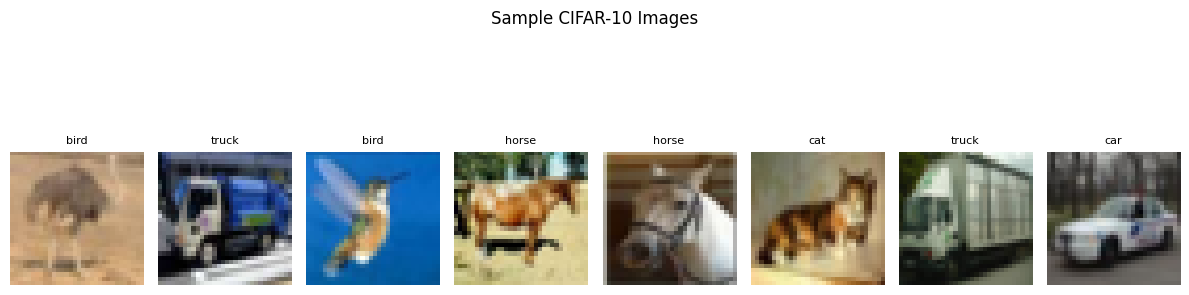

Train: 50000 | Val: 5000 | Test: 10000


In [ ]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path.cwd().parent / 'src'))

from data import get_dataloaders

trainloader, valloader, testloader, trainset, valset, testset = get_dataloaders()
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    img = images[i] / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(classes[labels[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}')

## Flatten an Image into a 3072-d Vector

The MLP requires images to be flattened from (3, 32, 32) into a single 3072-element
vector. Below is one sample image alongside its flattened representation.

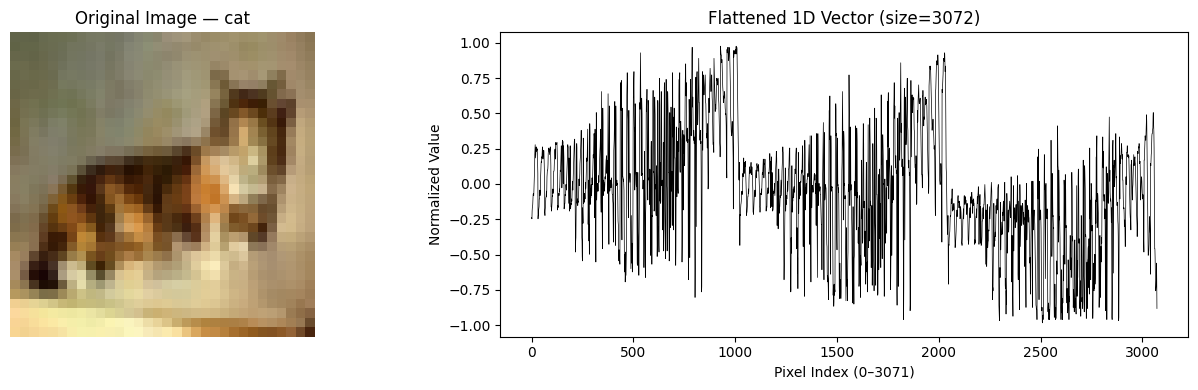

Image shape: torch.Size([3, 32, 32])  →  Flattened: (3072,)


In [ ]:
sample_img = images[5]
flat = sample_img.view(-1).numpy()

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
img = sample_img / 2 + 0.5
plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title(f'Original Image — {classes[labels[5]]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(flat, linewidth=0.5, color='black')
plt.title(f'Flattened 1D Vector (size={len(flat)})')
plt.xlabel('Pixel Index (0–3071)')
plt.ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('../results/figures/flattened_vector.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Image shape: {sample_img.shape}  →  Flattened: {flat.shape}")

## Summary

This notebook loads CIFAR-10 (50,000 train / 10,000 test images across 10 classes),
applies normalization (mean=0.5, std=0.5 per channel), and visualizes sample images
alongside their labels. We also demonstrate flattening a single 32×32×3 image into a
3072-element 1D vector — this is the input format required by the MLP in notebook 02,
since fully-connected layers expect flat feature vectors rather than spatial grids.

Subsequent notebooks (02–04) each call `get_dataloaders()` independently, so this
notebook is exploratory only and isn't a dependency for anything downstream.